In [2]:
import sys
#import ocean_model_grid_generator as ogg
import math
from pathlib import Path

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from glob import glob
import scipy as sp
import xarray as xr
import scipy.interpolate
import scipy.ndimage
from tqdm import tqdm_notebook
import cartopy.crs as ccrs

PI_180 = np.pi/180.

PLOT_DIR = Path('/g/data/tm70/ek4684/ocean_model_grid_generator_access_om3')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})


def polish_axes(ax, hide_ticks=False):
    if hide_ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.tick_params(axis='both', which='both', labelsize=10)
    for spine in ax.spines.values():
        spine.set_alpha(0.35)


/g/data/tm70/ek4684/conda-envs/basemap_py311_persistent/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
New05 = nc.Dataset('/g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/ocean_hgrid.nc')
Orig05 = nc.Dataset('/g/data/ik11/inputs/access-om2/input_b72797e1/mom_1deg/ocean_hgrid.nc')

In [4]:
New05

<class 'netCDF4.Dataset'>
root group (NETCDF3_64BIT_OFFSET data model, file format NETCDF3):
    history: This grid file was generated via command ocean_grid_generator.py -r 1 --no_south_cap --ensure_nj_even --bipolar_lower_lat 65 --mercator_lower_lat -75 --mercator_upper_lat 65 --match_dy so --south_ocean_lower_lat -81 --lower-lon -280.0 --enhanced_equatorial 2 on 2026-02-10 on platform gadi-login-06.gadi.nci.org.au
    description: This is an orthogonal coordinate grid for the Earth with a nominal resoution of 1.0 degrees along the equator. It consists of; a Mercator grid spanning -75.08457688315937 to 64.6539935310628 degrees; a bipolar northern cap north of 64.6539935310628 degrees; a regular lat-lon grid spanning -75.08457688315937 to -81.0 degrees; 
    source: ocean_grid_generator.py had git hash 2e945eb6a0e0d2d2bd983b088bd0861bb906b6d4 , But was localy Modified!. To obtain the grid generating code do: git clone https://github.com/ACCESS-NRI/ocean_model_grid_generator ;  git che

In [5]:
# Extract the variables
x = Orig05.variables['x'][:]
y = Orig05.variables['y'][:]
dx = Orig05.variables['dx'][:]
dx_new = New05.variables['dx'][:]
dy = Orig05.variables['dy'][:]
dy_new = New05.variables['dy'][:]
area = Orig05.variables['area'][:]
area_new = New05.variables['area'][:]
angle_dx = Orig05.variables['angle_dx'][:]
angle_dx_new = New05.variables['angle_dx'][:]

# T-grid latitude/longitude points
tlat_new05 = New05.variables['y'][1::2, 1::2]
tlon_new05 = New05.variables['x'][1::2, 1::2]
geolon = Orig05.variables['x'][1::2, 1::2]
geolat = Orig05.variables['y'][1::2, 1::2]

print(f'tlat_orig_min: {geolat.min()}, max: {geolat.max()}')
print(f'tlon_orig_min: {geolon.min()}, max: {geolon.max()}')
print(f'tlat_new min: {tlat_new05.min()}, max: {tlat_new05.max()}')
print(f'tlon_new min: {tlon_new05.min()}, max: {tlon_new05.max()}')


tlat_orig_min: -77.87662337662337, max: 89.74870688112713
tlon_orig_min: -279.9911230861013, max: 79.99112308610133
tlat_new min: -80.87140655517578, max: 89.80342864990234
tlon_new min: -279.9936218261719, max: 79.99360656738281


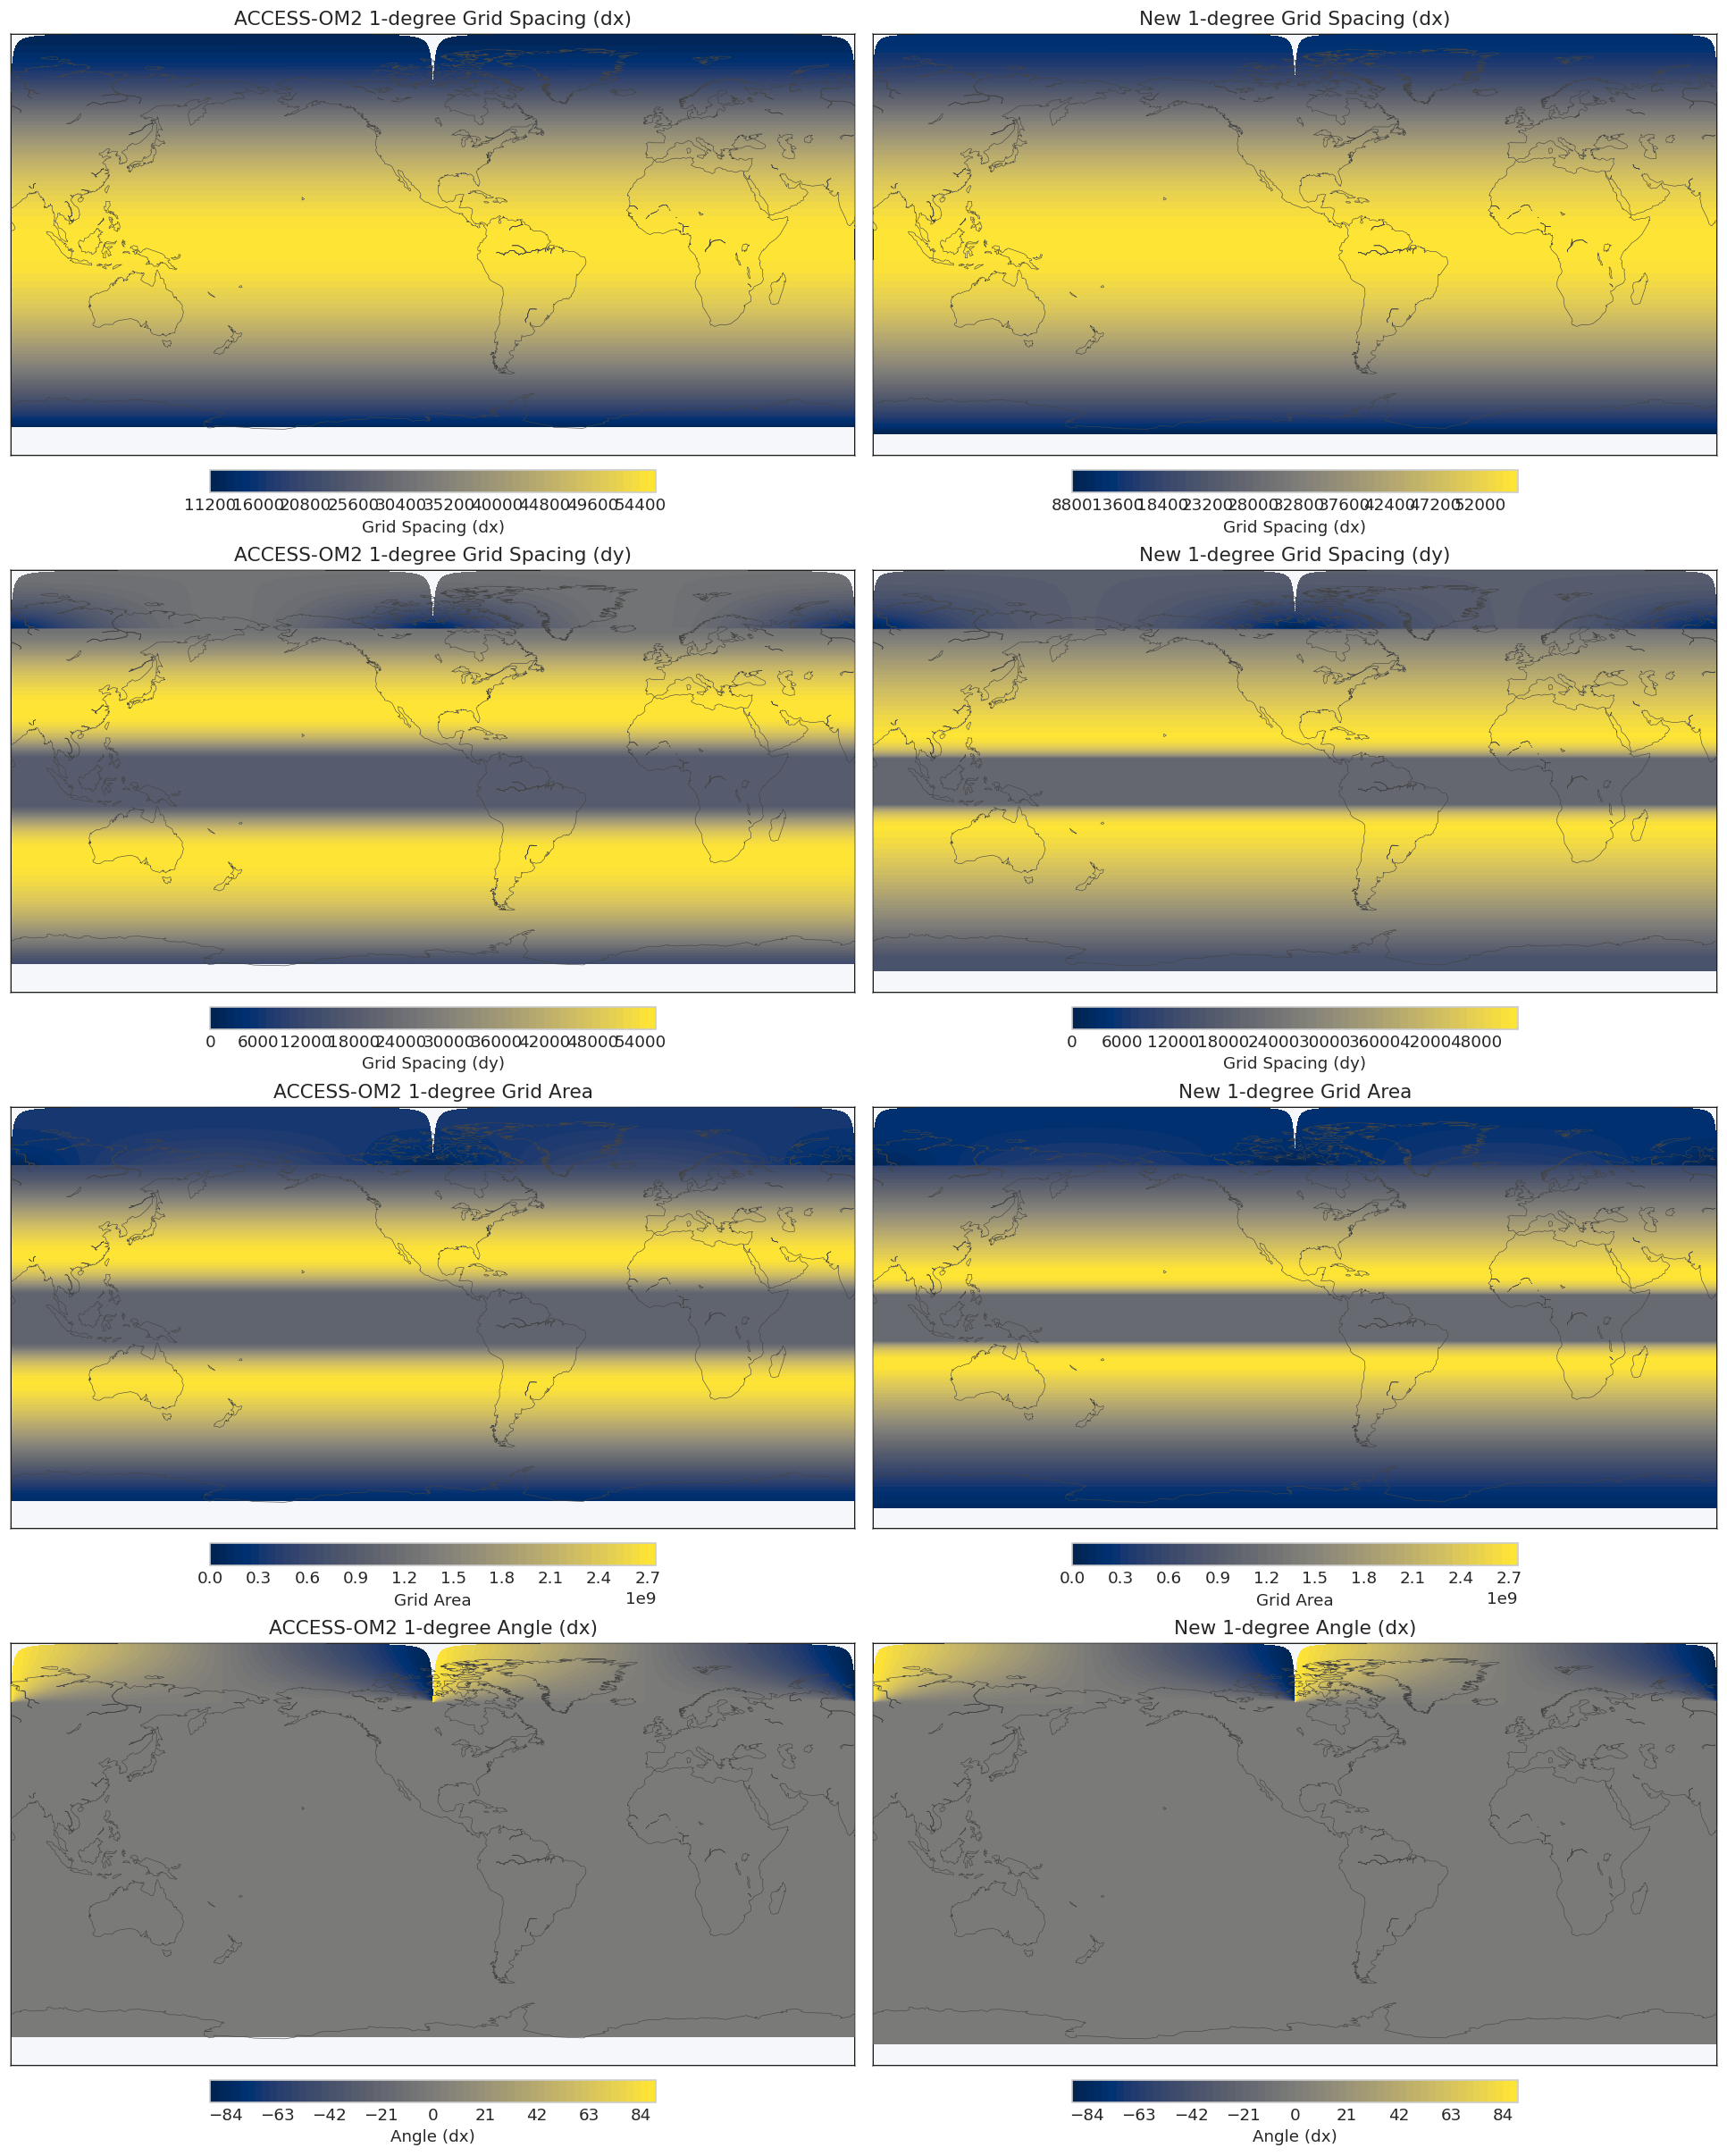

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/grid_compare_metrics_100km.png


In [6]:
# Define the variables to plot
variables = ['dx', 'dy', 'area', 'angle_dx']
titles = ['Grid Spacing (dx)', 'Grid Spacing (dy)', 'Grid Area', 'Angle (dx)']
orig_data = [dx, dy, area, angle_dx]
new_data = [dx_new, dy_new, area_new, angle_dx_new]

fig, axes = plt.subplots(len(variables), 2, figsize=(16, 5 * len(variables)), constrained_layout=True)

for i, title in enumerate(titles):
    # ACCESS-OM2 panel
    map1 = Basemap(
        projection='cyl',
        llcrnrlat=-90,
        urcrnrlat=90,
        llcrnrlon=-280,
        urcrnrlon=80,
        resolution='c',
        ax=axes[i, 0],
    )
    map1.drawmapboundary(fill_color='#f5f7fa')
    map1.drawcoastlines(linewidth=0.35, color='#444444')
    X, Y = map1(geolon, geolat)
    p1 = map1.contourf(X, Y, orig_data[i][1::2, 1::2], levels=60, cmap='cividis')
    axes[i, 0].set_title(f'ACCESS-OM2 1-degree {title}')
    polish_axes(axes[i, 0], hide_ticks=True)

    # New grid panel
    map2 = Basemap(
        projection='cyl',
        llcrnrlat=-90,
        urcrnrlat=90,
        llcrnrlon=-280,
        urcrnrlon=80,
        resolution='c',
        ax=axes[i, 1],
    )
    map2.drawmapboundary(fill_color='#f5f7fa')
    map2.drawcoastlines(linewidth=0.35, color='#444444')
    X_new, Y_new = map2(tlon_new05, tlat_new05)
    p2 = map2.contourf(X_new, Y_new, new_data[i][1::2, 1::2], levels=60, cmap='cividis')
    axes[i, 1].set_title(f'New 1-degree {title}')
    polish_axes(axes[i, 1], hide_ticks=True)

    cbar1 = fig.colorbar(p1, ax=axes[i, 0], orientation='horizontal', fraction=0.05, pad=0.03)
    cbar1.set_label(title)
    cbar2 = fig.colorbar(p2, ax=axes[i, 1], orientation='horizontal', fraction=0.05, pad=0.03)
    cbar2.set_label(title)

out = PLOT_DIR / 'grid_compare_metrics_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


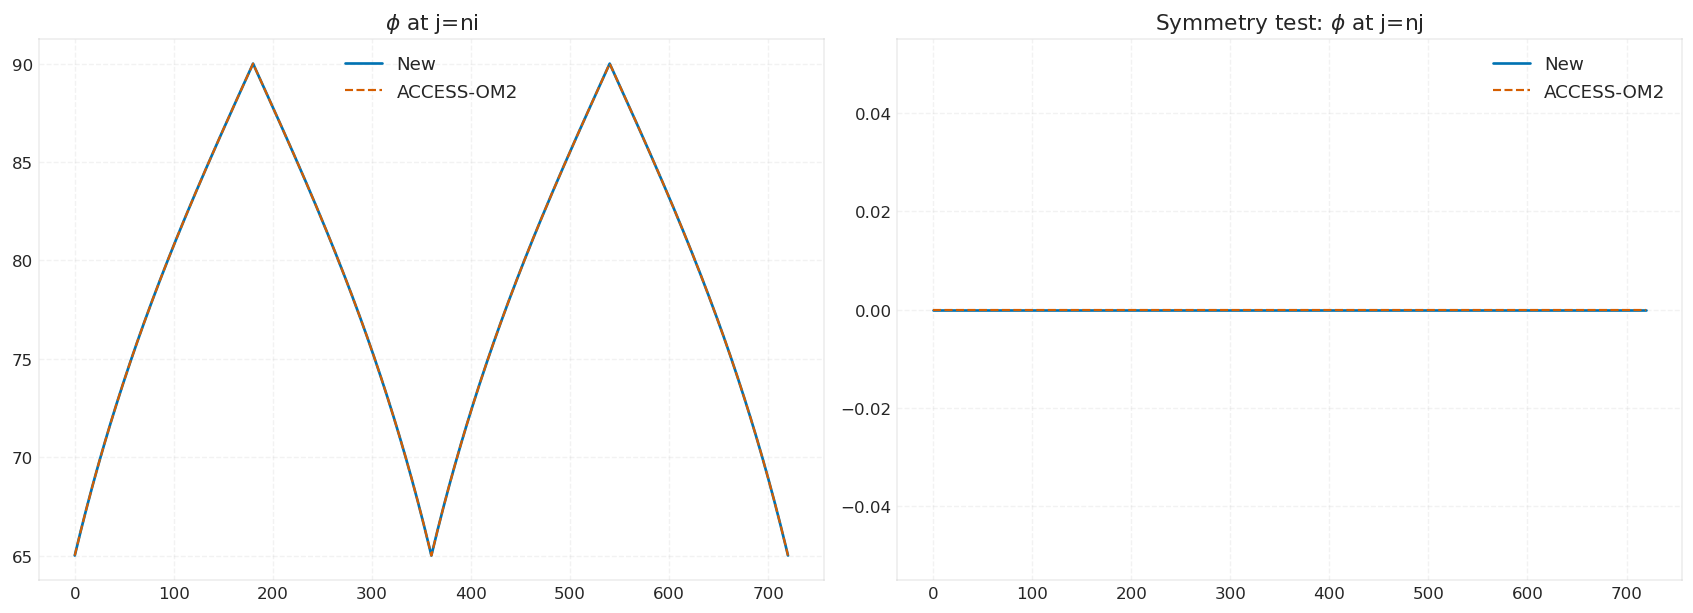

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/phi_edge_symmetry_100km.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(New05['y'][-1, :], label='New', color='#0072B2', linewidth=1.6)
axes[0].plot(Orig05['y'][-1, :], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[0].set_title('$\phi$ at j=ni')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.25, linestyle='--')
polish_axes(axes[0], hide_ticks=False)

axes[1].plot(New05['y'][-2, :] - New05['y'][-2, ::-1], label='New', color='#0072B2', linewidth=1.6)
axes[1].plot(Orig05['y'][-1, :] - Orig05['y'][-1, ::-1], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[1].set_title('Symmetry test: $\phi$ at j=nj')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.25, linestyle='--')
polish_axes(axes[1], hide_ticks=False)

out = PLOT_DIR / 'phi_edge_symmetry_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


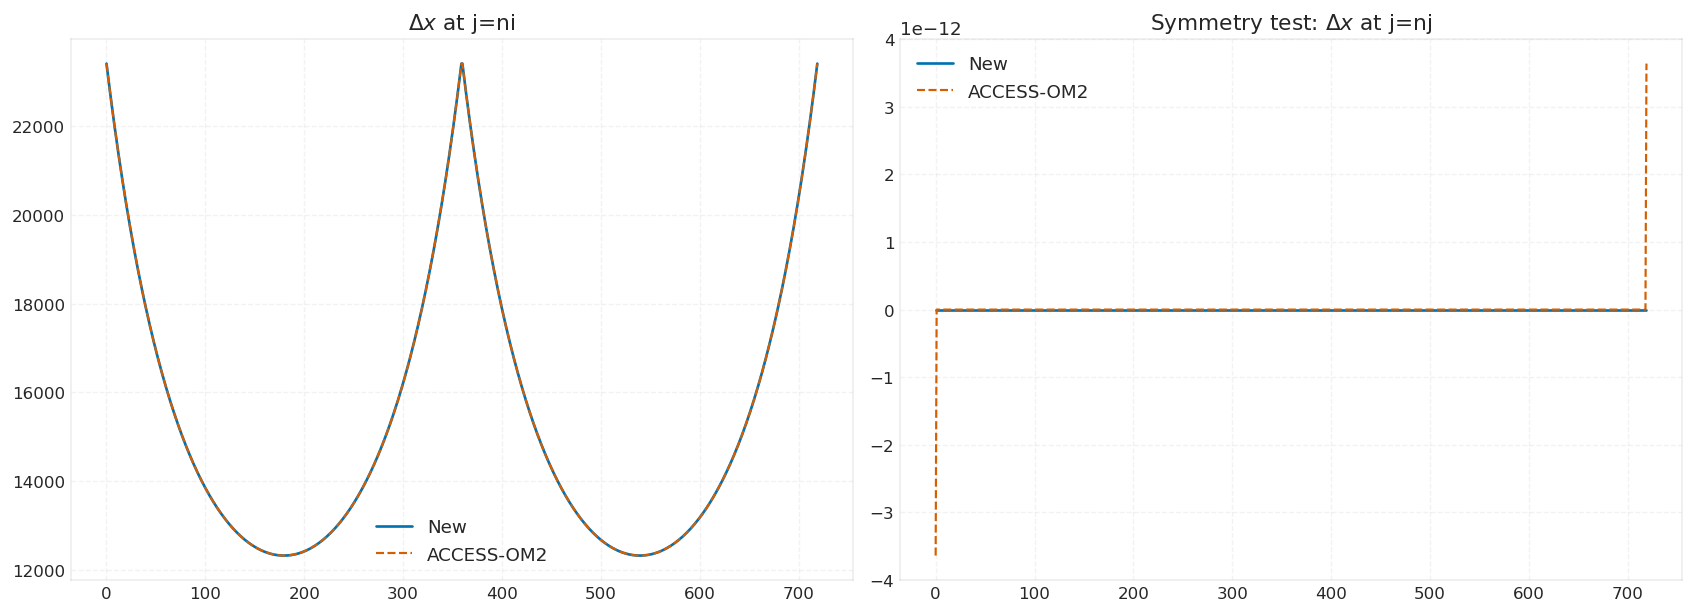

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/dx_edge_symmetry_100km.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(New05['dx'][-1, :], label='New', color='#0072B2', linewidth=1.6)
axes[0].plot(Orig05['dx'][-1, :], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[0].set_title('$\Delta x$ at j=ni')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.25, linestyle='--')
polish_axes(axes[0], hide_ticks=False)

axes[1].plot(New05['dx'][-2, :] - New05['dx'][-2, ::-1], label='New', color='#0072B2', linewidth=1.6)
axes[1].plot(Orig05['dx'][-1, :] - Orig05['dx'][-1, ::-1], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[1].set_title('Symmetry test: $\Delta x$ at j=nj')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.25, linestyle='--')
polish_axes(axes[1], hide_ticks=False)

out = PLOT_DIR / 'dx_edge_symmetry_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


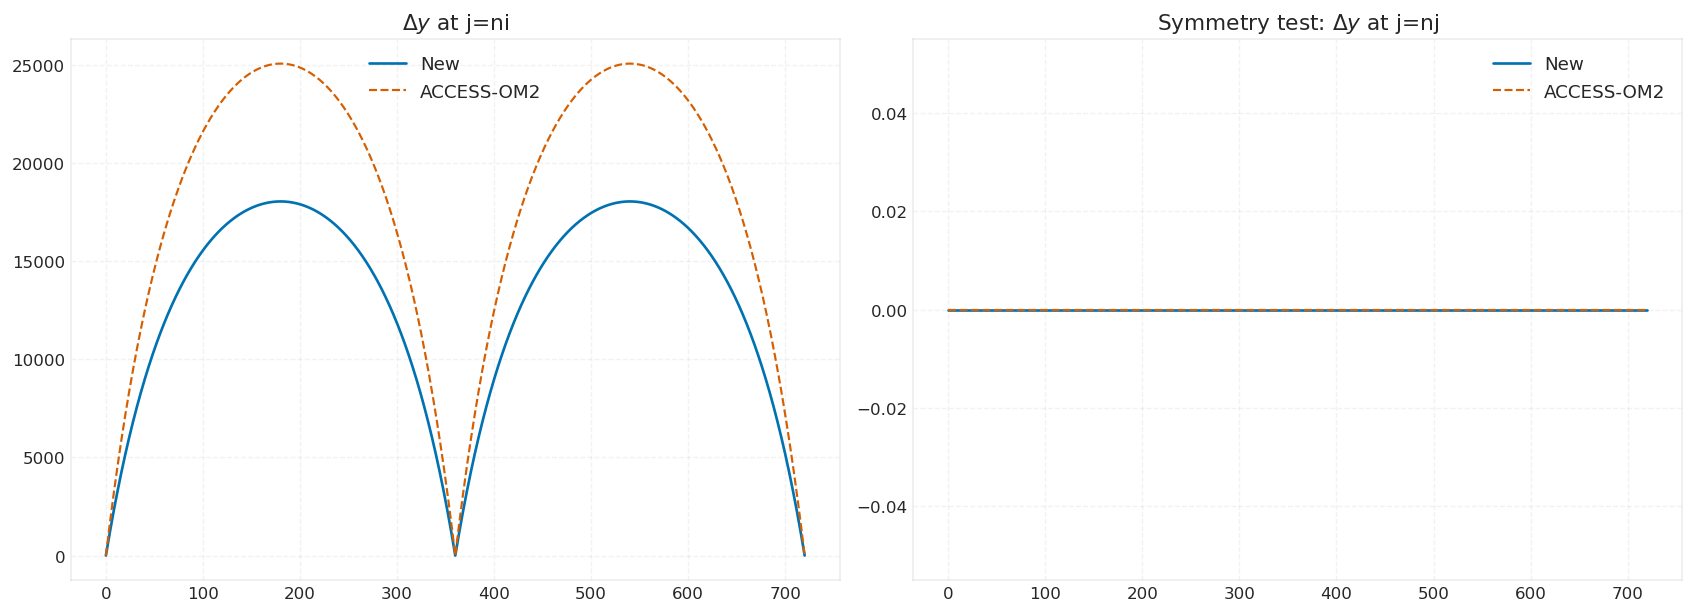

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/dy_edge_symmetry_100km.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(New05['dy'][-1, :], label='New', color='#0072B2', linewidth=1.6)
axes[0].plot(Orig05['dy'][-1, :], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[0].set_title('$\Delta y$ at j=ni')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.25, linestyle='--')
polish_axes(axes[0], hide_ticks=False)

axes[1].plot(New05['dy'][-1, :] - New05['dy'][-1, ::-1], label='New', color='#0072B2', linewidth=1.6)
axes[1].plot(Orig05['dy'][-1, :] - Orig05['dy'][-1, ::-1], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[1].set_title('Symmetry test: $\Delta y$ at j=nj')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.25, linestyle='--')
polish_axes(axes[1], hide_ticks=False)

out = PLOT_DIR / 'dy_edge_symmetry_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


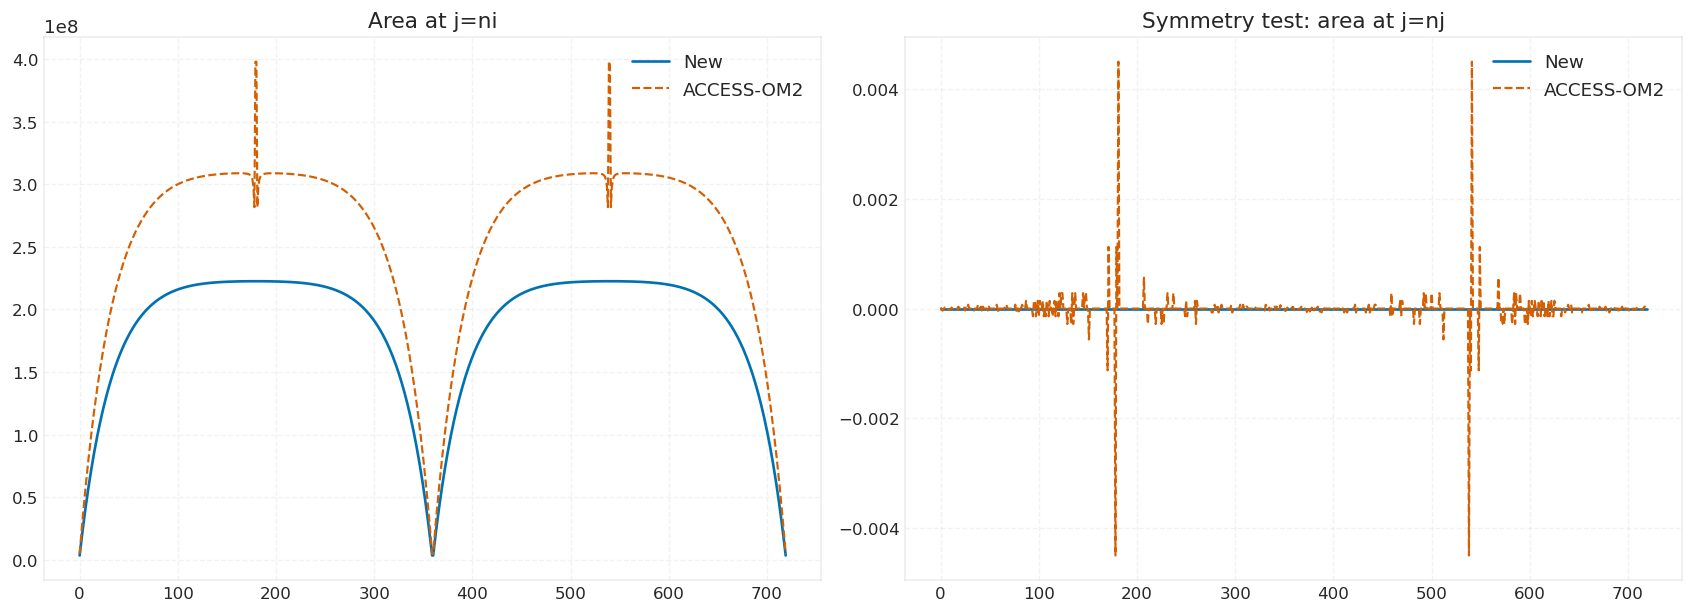

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/area_edge_symmetry_100km.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(New05['area'][-1, :], label='New', color='#0072B2', linewidth=1.6)
axes[0].plot(Orig05['area'][-1, :], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[0].set_title('Area at j=ni')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.25, linestyle='--')
polish_axes(axes[0], hide_ticks=False)

axes[1].plot(New05['area'][-1, :] - New05['area'][-1, ::-1], label='New', color='#0072B2', linewidth=1.6)
axes[1].plot(Orig05['area'][-1, :] - Orig05['area'][-1, ::-1], label='ACCESS-OM2', color='#D55E00', linewidth=1.3, linestyle='--')
axes[1].set_title('Symmetry test: area at j=nj')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.25, linestyle='--')
polish_axes(axes[1], hide_ticks=False)

out = PLOT_DIR / 'area_edge_symmetry_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


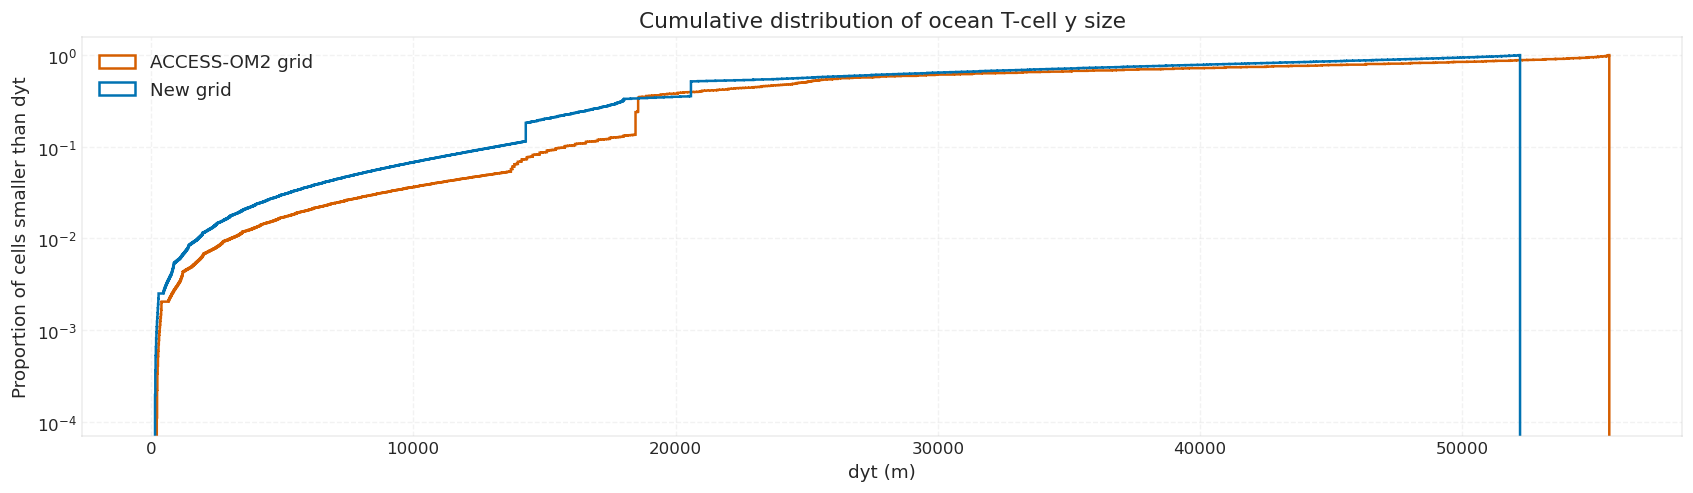

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/dy_cumulative_distribution_100km.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
ax.hist(
    np.ma.ravel(Orig05.variables['dy'][1::2, 1::2]),
    bins=5000,
    log=True,
    density=True,
    histtype='step',
    cumulative=True,
    label='ACCESS-OM2 grid',
    color='#D55E00',
    linewidth=1.5,
)
ax.hist(
    np.ma.ravel(New05.variables['dy'][1::2, 1::2]),
    bins=5000,
    log=True,
    density=True,
    histtype='step',
    cumulative=True,
    label='New grid',
    color='#0072B2',
    linewidth=1.5,
)
ax.grid(alpha=0.25, linestyle='--')
ax.set_xlabel('dyt (m)')
ax.set_ylabel('Proportion of cells smaller than dyt')
ax.set_title('Cumulative distribution of ocean T-cell y size')
ax.legend(loc='best')
polish_axes(ax, hide_ticks=False)

out = PLOT_DIR / 'dy_cumulative_distribution_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


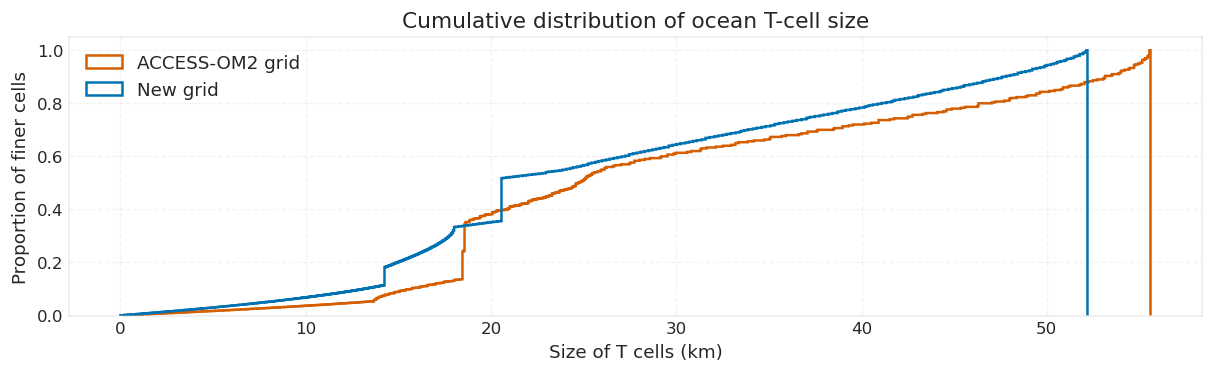

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/tcell_size_cumulative_100km.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
ax.hist(
    np.ma.ravel(dy / 1000),
    bins=1000,
    density=True,
    histtype='step',
    cumulative=True,
    label='ACCESS-OM2 grid',
    color='#D55E00',
    linewidth=1.5,
)
ax.hist(
    np.ma.ravel(dy_new / 1000),
    bins=1000,
    density=True,
    histtype='step',
    cumulative=True,
    label='New grid',
    color='#0072B2',
    linewidth=1.5,
)
ax.grid(alpha=0.25, linestyle='--')
ax.set_xlabel('Size of T cells (km)')
ax.set_ylabel('Proportion of finer cells')
ax.set_title('Cumulative distribution of ocean T-cell size')
ax.legend(loc='best')
polish_axes(ax, hide_ticks=False)

out = PLOT_DIR / 'tcell_size_cumulative_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


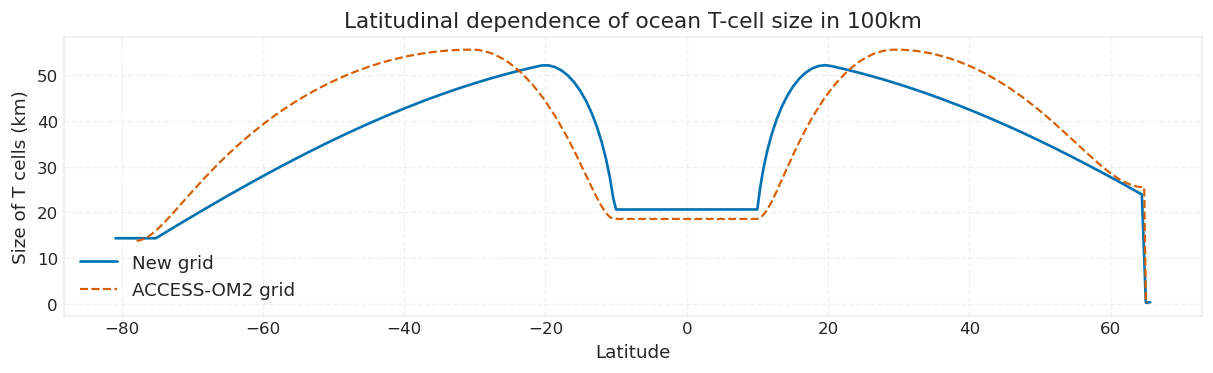

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/latitudinal_tcell_size_100km.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
ax.plot(tlat_new05[:840, 1], dy_new[1:1680:2, 1] / 1000, label='New grid', color='#0072B2', linewidth=1.6)
ax.plot(y[1:1680:2, 1], dy[1:1680:2, 1] / 1000, label='ACCESS-OM2 grid', color='#D55E00', linewidth=1.3, linestyle='--')
ax.set_ylabel('Size of T cells (km)')
ax.set_xlabel('Latitude')
ax.set_title('Latitudinal dependence of ocean T-cell size in 100km')
ax.legend(loc='best')
ax.grid(alpha=0.25, linestyle='--')
polish_axes(ax, hide_ticks=False)

out = PLOT_DIR / 'latitudinal_tcell_size_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


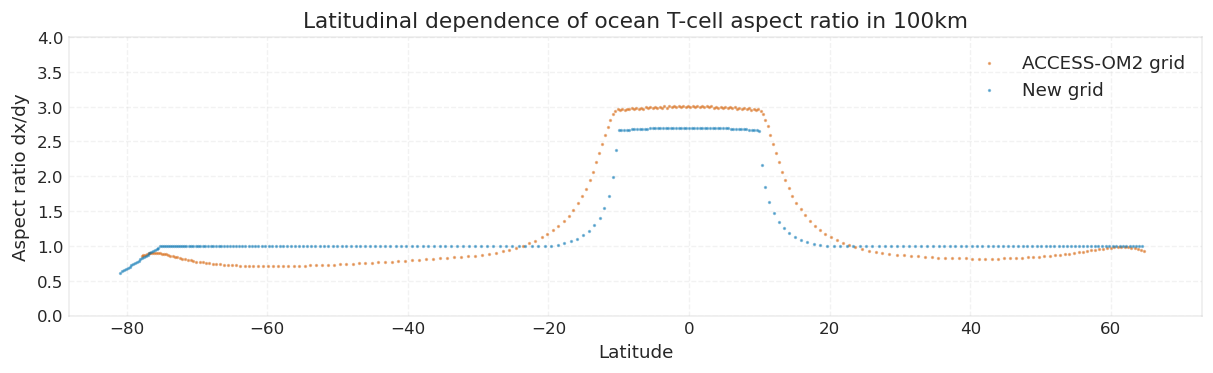

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/grid_scatter_100km.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
ax.scatter(y[1::2, 1], (dx[1::2, 1] / dy[1::2, 1]), s=1.0, label='ACCESS-OM2 grid', color='#D55E00', alpha=0.45)
ax.scatter(tlat_new05[:, 1], (dx_new[1::2, 1] / dy_new[1::2, 1]), s=1.0, label='New grid', color='#0072B2', alpha=0.45)
ax.set_ylabel('Aspect ratio dx/dy')
ax.set_xlabel('Latitude')
ax.set_title('Latitudinal dependence of ocean T-cell aspect ratio in 100km')
ax.set_ylim(top=4, bottom =0)
ax.legend(loc='best')
ax.grid(alpha=0.25, linestyle='--')
polish_axes(ax, hide_ticks=False)

out = PLOT_DIR / 'grid_scatter_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


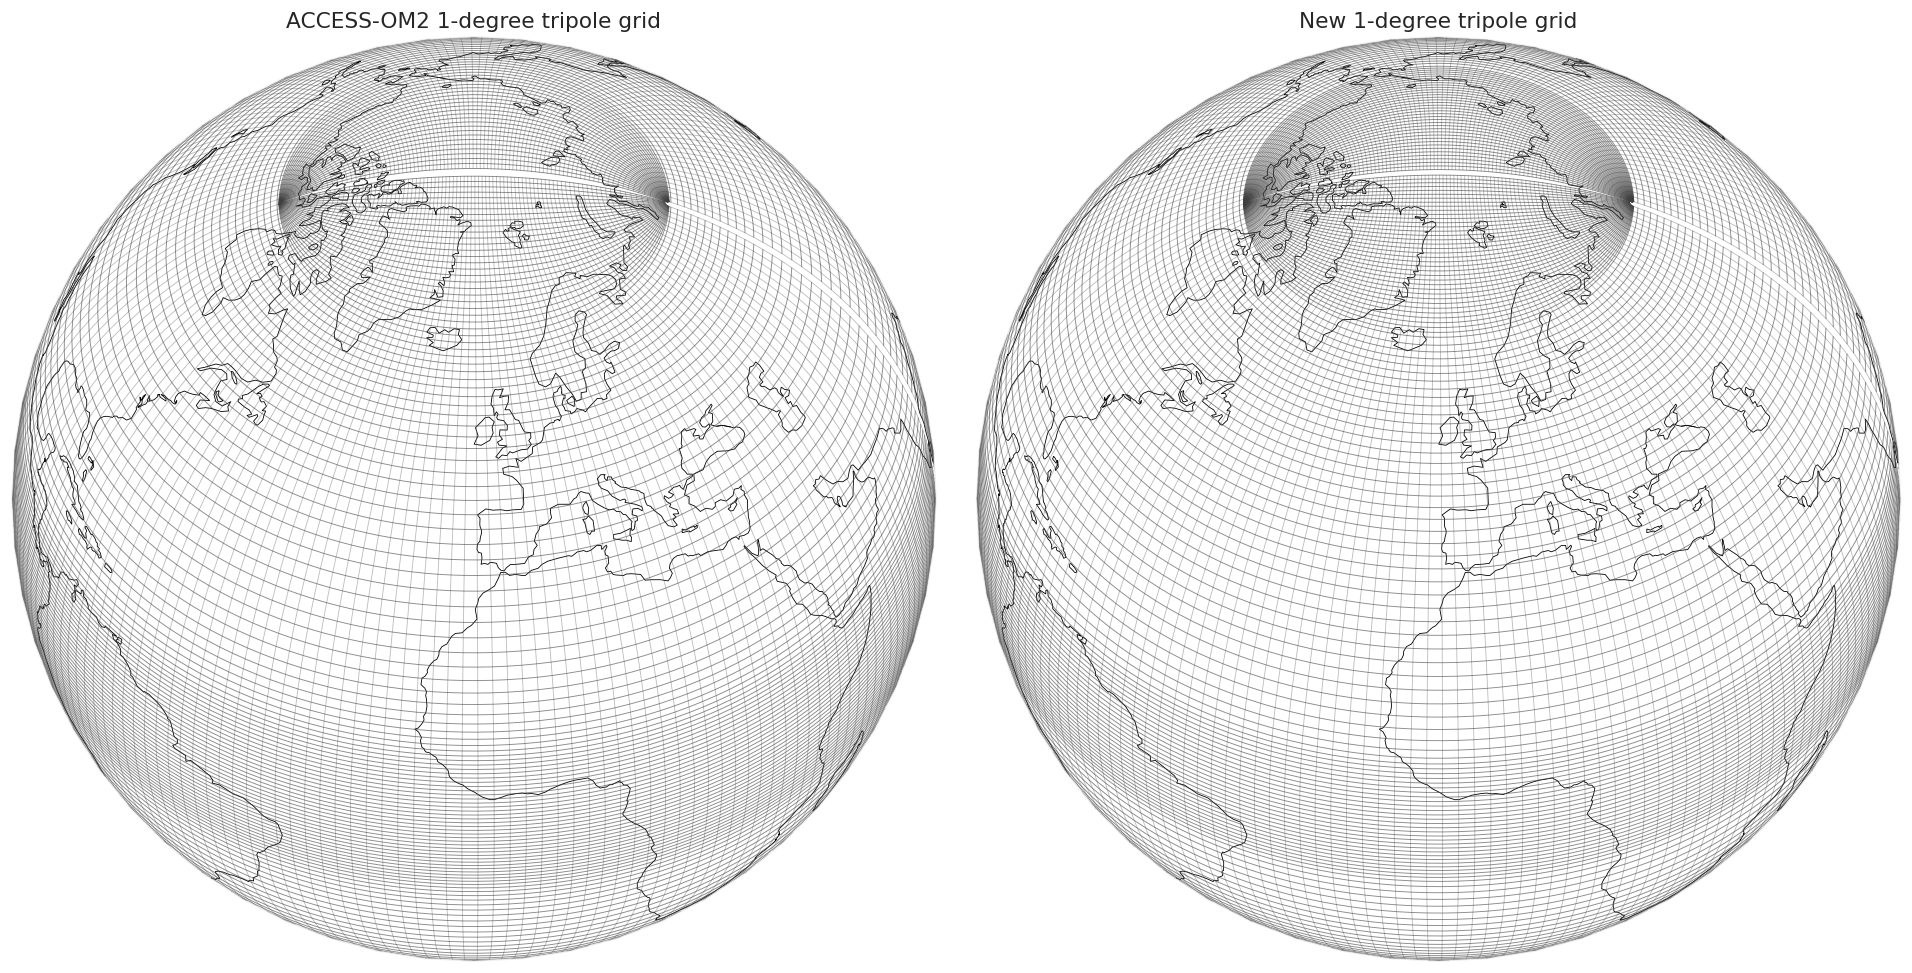

Saved: /g/data/tm70/ek4684/ocean_model_grid_generator_access_om3/grid_tripole_100km.png


In [15]:
# Define the subset of grid data
subset_x_orig = Orig05.variables['x'][1::4, 1::4]
subset_y_orig = Orig05.variables['y'][1::4, 1::4]
subset_x_new = New05.variables['x'][1::4, 1::4]
subset_y_new = New05.variables['y'][1::4, 1::4]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.Orthographic(-10, 45)},
    constrained_layout=True,
)

ax1 = axes[0]
ax1.set_global()
ax1.coastlines(linewidth=0.5)
ax1.plot(subset_x_orig, subset_y_orig, transform=ccrs.PlateCarree(), color='#6A6A6A', alpha=0.45, linewidth=0.5)
ax1.plot(subset_x_orig.T, subset_y_orig.T, transform=ccrs.PlateCarree(), color='#3F3F3F', alpha=0.6, linewidth=0.55)
ax1.set_title('ACCESS-OM2 1-degree tripole grid')
polish_axes(ax1, hide_ticks=True)

ax2 = axes[1]
ax2.set_global()
ax2.coastlines(linewidth=0.5)
ax2.plot(subset_x_new, subset_y_new, transform=ccrs.PlateCarree(), color='#6A6A6A', alpha=0.45, linewidth=0.5)
ax2.plot(subset_x_new.T, subset_y_new.T, transform=ccrs.PlateCarree(), color='#3F3F3F', alpha=0.6, linewidth=0.55)
ax2.set_title('New 1-degree tripole grid')
polish_axes(ax2, hide_ticks=True)

out = PLOT_DIR / 'grid_tripole_100km.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')
